# FW CADIS Weight Windows

Creating and utilizing a weight window to accelerate deep shielding simulations

This example simulates a shield room / bunker with corridor entrance and a neutron source in the center of the room. This example implements a FW-CADIS of weight window generation. 

In this tutorial we shall focus on generating a weight window to accelerate the simulation of particles through a shield.

Weight Windows are found using the FW-CADIS method and used to accelerate the simulation.

The variance reduction method used for this simulation is well documented in the OpenMC documentation
https://docs.openmc.org/en/stable/usersguide/variance_reduction.html


First we import ```openmc``` and other packages needed for the example and configure the nuclear data path

In [1]:
import time  # used to time the simulation
import numpy as np
import copy

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm  # used for plotting log scale graphs

import openmc
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'


We create a couple of materials for the simulation

In [2]:
mat_air = openmc.Material(name="air")
mat_air.add_element("N", 0.784431)
mat_air.add_element("O", 0.210748)
mat_air.add_element("Ar", 0.0046)
mat_air.set_density("g/cc", 0.001205)

mat_concrete = openmc.Material(name='concrete')
mat_concrete.add_element("H",0.168759)
mat_concrete.add_element("C",0.001416)
mat_concrete.add_element("O",0.562524)
mat_concrete.add_element("Na",0.011838)
mat_concrete.add_element("Mg",0.0014)
mat_concrete.add_element("Al",0.021354)
mat_concrete.add_element("Si",0.204115)
mat_concrete.add_element("K",0.005656)
mat_concrete.add_element("Ca",0.018674)
mat_concrete.add_element("Fe",0.00426)
mat_concrete.set_density("g/cm3", 2.3)

materials_continuous_xs = openmc.Materials([mat_air, mat_concrete])

Now we define and plot the geometry. This geometry is defined by parameters for every width and height. The parameters input into the geometry in a stacked manner so they can easily be adjusted to change the geometry without creating overlapping cells.

In [3]:
width_a = 100
width_b = 100
width_c = 500
width_d = 100
width_e = 100
width_f = 100
width_g = 100

depth_a = 100
depth_b = 100
depth_c = 700
depth_d = 600
depth_e = 100
depth_f = 100

height_j = 100
height_k = 500
height_l = 100

xplane_0 = openmc.XPlane(x0=0, boundary_type="vacuum")
xplane_1 = openmc.XPlane(x0=xplane_0.x0 + width_a)
xplane_2 = openmc.XPlane(x0=xplane_1.x0 + width_b)
xplane_3 = openmc.XPlane(x0=xplane_2.x0 + width_c)
xplane_4 = openmc.XPlane(x0=xplane_3.x0 + width_d)
xplane_5 = openmc.XPlane(x0=xplane_4.x0 + width_e)
xplane_6 = openmc.XPlane(x0=xplane_5.x0 + width_f)
xplane_7 = openmc.XPlane(x0=xplane_6.x0 + width_g, boundary_type="vacuum")

yplane_0 = openmc.YPlane(y0=0, boundary_type="vacuum")
yplane_1 = openmc.YPlane(y0=yplane_0.y0 + depth_a)
yplane_2 = openmc.YPlane(y0=yplane_1.y0 + depth_b)
yplane_3 = openmc.YPlane(y0=yplane_2.y0 + depth_c)
yplane_4 = openmc.YPlane(y0=yplane_3.y0 + depth_d)
yplane_5 = openmc.YPlane(y0=yplane_4.y0 + depth_e)
yplane_6 = openmc.YPlane(y0=yplane_5.y0 + depth_f, boundary_type="vacuum")

zplane_1 = openmc.ZPlane(z0=0, boundary_type="vacuum")
zplane_2 = openmc.ZPlane(z0=zplane_1.z0 + height_j)
zplane_3 = openmc.ZPlane(z0=zplane_2.z0 + height_k)
zplane_4 = openmc.ZPlane(z0=zplane_3.z0 + height_l, boundary_type="vacuum")

outside_left_region = +xplane_0 & -xplane_1 & +yplane_1 & -yplane_5 & +zplane_1 & -zplane_4
wall_left_region = +xplane_1 & -xplane_2 & +yplane_2 & -yplane_4 & +zplane_2 & -zplane_3
wall_right_region = +xplane_5 & -xplane_6 & +yplane_2 & -yplane_5 & +zplane_2 & -zplane_3
wall_top_region = +xplane_1 & -xplane_4 & +yplane_4 & -yplane_5 & +zplane_2 & -zplane_3
outside_top_region = +xplane_0 & -xplane_7 & +yplane_5 & -yplane_6 & +zplane_1 & -zplane_4
wall_bottom_region = +xplane_1 & -xplane_6 & +yplane_1 & -yplane_2 & +zplane_2 & -zplane_3
outside_bottom_region = +xplane_0 & -xplane_7 & +yplane_0 & -yplane_1 & +zplane_1 & -zplane_4
wall_middle_region = +xplane_3 & -xplane_4 & +yplane_3 & -yplane_4 & +zplane_2 & -zplane_3
outside_right_region = +xplane_6 & -xplane_7 & +yplane_1 & -yplane_5 & +zplane_1 & -zplane_4

room_region = +xplane_2 & -xplane_3 & +yplane_2 & -yplane_4 & +zplane_2 & -zplane_3
gap_region = +xplane_3 & -xplane_4 & +yplane_2 & -yplane_3 & +zplane_2 & -zplane_3
corridor_region = +xplane_4 & -xplane_5 & +yplane_2 & -yplane_5 & +zplane_2 & -zplane_3

roof_region = +xplane_1 & -xplane_6 & +yplane_1 & -yplane_5 & +zplane_1 & -zplane_2
floor_region = +xplane_1 & -xplane_6 & +yplane_1 & -yplane_5 & +zplane_3 & -zplane_4

outside_left_cell = openmc.Cell(region=outside_left_region, fill=mat_air)
outside_right_cell = openmc.Cell(region=outside_right_region, fill=mat_air)
outside_top_cell = openmc.Cell(region=outside_top_region, fill=mat_air)
outside_bottom_cell = openmc.Cell(region=outside_bottom_region, fill=mat_air)
wall_left_cell = openmc.Cell(region=wall_left_region, fill=mat_concrete)
wall_right_cell = openmc.Cell(region=wall_right_region, fill=mat_concrete)
wall_top_cell = openmc.Cell(region=wall_top_region, fill=mat_concrete)
wall_bottom_cell = openmc.Cell(region=wall_bottom_region, fill=mat_concrete)
wall_middle_cell = openmc.Cell(region=wall_middle_region, fill=mat_concrete)
room_cell = openmc.Cell(region=room_region, fill=mat_air)
gap_cell = openmc.Cell(region=gap_region, fill=mat_air)
corridor_cell = openmc.Cell(region=corridor_region, fill=mat_air)

roof_cell = openmc.Cell(region=roof_region, fill=mat_concrete)
floor_cell = openmc.Cell(region=floor_region, fill=mat_concrete)

geometry = openmc.Geometry(
    [
        outside_bottom_cell,
        outside_top_cell,
        outside_left_cell,
        outside_right_cell,
        wall_left_cell,
        wall_right_cell,
        wall_top_cell,
        wall_bottom_cell,
        wall_middle_cell,
        room_cell,
        gap_cell,
        corridor_cell,
        roof_cell,
        floor_cell,
    ]
)

Now we plot the geometry and color by materials.

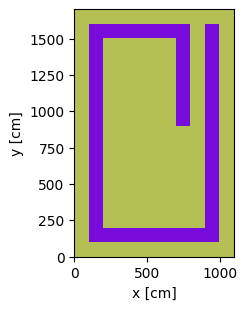

In [4]:
plot = geometry.plot(basis='xy',  color_by='material')
plot.figure.savefig('geometry_top_down_view.png', bbox_inches="tight")

Next we create a point source, this also uses the same geometry parameters to place in the center of the room regardless of the values of the parameters.

In [5]:
# location of the point source
source_x = width_a + width_b + width_c * 0.5
source_y = depth_a + depth_b + depth_c * 0.75
source_z = height_j + height_k * 0.5
space = openmc.stats.Point((source_x, source_y, source_z))

# all (100%) of source particles are 2.5MeV energy
source = openmc.IndependentSource(
    space=space,
    angle=openmc.stats.Isotropic(),
    energy=openmc.stats.Discrete([2.5e6], [1.0]),
    particle="neutron"
)

Make the settings for our continuous energy MC solver

In [6]:
# Create settings
settings = openmc.Settings()
settings.run_mode = "fixed source"
settings.source = source
settings.particles = 80
settings.batches = 100
# Normally in fixed source problems we don't use inactivie batches.
# However when using Random Ray we do need to use inactive batches
# More info here https://docs.openmc.org/en/stable/usersguide/random_ray.html#batches
settings.inactive = 50

ce_model = openmc.Model(geometry, materials_continuous_xs, settings)

At this point, we have a valid continuous energy Monte Carlo model!

# Convert to Multigroup and Random Ray

We begin by making a clone of our original continuous energy deck, and then convert it to multigroup.

This step will automatically compute material-wise multigroup cross sections for us by running a continous energy OpenMC simulation internally.

In [7]:
rr_model = copy.deepcopy(ce_model)
rr_model.convert_to_multigroup(
    # I tend to use "stochastic_slab" method here.
    # Using the "material_wise" method is more accurate but slower
    # In problems where one needs weight windows to solve we don't really want
    # the calculation of weight windows to be slow.
    # In extreme cases the "material_wise" method could require its own weight windows to solve.
    # The "stochastic_slab" method is much faster and works well for most problems.
    # more details here https://docs.openmc.org/en/latest/usersguide/random_ray.html#the-easy-way
    method="stochastic_slab", 
    overwrite_mgxs_library=True,  # overrights the 
    nparticles=2000 # this is the default but can be adjusted upward to improve the fidelity of the generated cross section library
)

/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=40.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=2.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=11.
  warn(msg, IDWarning)


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5
 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5
 Reading Ar36 from /home/jon/nuclear_data/neutron/Ar36.h5
 Reading Ar38 from /home/jon/nuclear_data/neutron/Ar38.h5
 Reading Ar40 from /home/jon/nuclear_data/neutron/Ar40.h5
 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Reading C12 from /home/jon/nuclear_data/neutron/C12.h5


 Reading C13 from /home/jon/nuclear_data/neutron/C13.h5
 Reading Na23 from /home/jon/nuclear_data/neutron/Na23.h5
 Reading Mg24 from /home/jon/nuclear_data/neutron/Mg24.h5


 Reading Mg25 from /home/jon/nuclear_data/neutron/Mg25.h5
 Reading Mg26 from /home/jon/nuclear_data/neutron/Mg26.h5
 Reading Al27 from /home/jon/nuclear_data/neutron/Al27.h5


...

 Simulating batch 195
 Simulating batch 196


 Simulating batch 197


 Simulating batch 198
 Simulating batch 199


 Simulating batch 200
 Creating state point statepoint.200.h5...



 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 3.9241e+00 seconds
   Reading cross sections          = 3.9062e+00 seconds
 Total time in simulation          = 3.9911e+01 seconds
   Time in transport only          = 3.5521e+01 seconds
   Time in active batches          = 3.9911e+01 seconds
   Time accumulating tallies       = 4.2523e+00 seconds
   Time writing statepoints        = 4.4733e-02 seconds
 Total time for finalization       = 1.8580e-06 seconds
 Total time elapsed                = 4.3855e+01 seconds
 Calculation Rate (active)         = 10022.2 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00000 +/- 0.00000



We now have a valid multigroup Monte Carlo input deck, complete with a "mgxs.h5" multigroup cross section library file. Next, we convert the model to use random ray instead of multigroup monte carlo.

Random ray is needed for use with the FW-CADIS algorithm (which requires global adjoint flux information that the random ray solver generates).

The below function will analyze the geometry and initialize the random ray solver with reasonable parameters.

Users are free to tweak these parameters to improve the performance of the random ray solver, but the defaults are likely sufficient for weight window generation purposes for most cases.

In [8]:
rr_model.convert_to_random_ray()

# Create a Mesh for: Tallies / Weight Windows / Random Ray Source Region Subdivision

Now we setup a mesh that will be used in three ways:
1. For a mesh flux tally for viewing results
2. For subdividing the random ray source regions into smaller cells
3. For computing weight window parameters on

In [9]:
mesh = openmc.RegularMesh().from_domain(geometry)
mesh.dimension = (100, 100, 1)
mesh.id = 1

# 1. Make a flux tally for viewing the results of the simulation
mesh_filter = openmc.MeshFilter(mesh)
flux_tally = openmc.Tally(name="flux tally")
flux_tally.filters = [mesh_filter]
flux_tally.scores = ["flux"]
flux_tally.id = 42  # we set the ID because we need to access this later
tallies = openmc.Tallies([flux_tally])

# 2. Subdivide random ray source regions
rr_model.settings.random_ray['source_region_meshes'] = [(mesh, [rr_model.geometry.root_universe])]

/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)
/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=42.
  warn(msg, IDWarning)


Not required for WW generation, but one can run the regular (forward flux) random ray solver to make sure things are working before we attempt to generate weight windows with the command ```random_ray_wwg_statepoint = rr_model.run()```

# Use FW-CADIS to Generate Weight Windows

Now add the weight window generator

In [10]:
rr_model.settings.weight_window_generators = openmc.WeightWindowGenerator(
    method='fw_cadis',
    mesh=mesh,
    max_realizations=settings.batches
)

Then run the random ray model. This will automatically run a normal forward flux solve followed by a subsequent adjoint solve that is used to compute the weight windows. Our outputted flux tally data will be in terms of adjoint fluxes.

In [11]:
random_ray_wwg_statepoint = rr_model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Simulating batch 2    (inactive)
 Simulating batch 3    (inactive)


 Simulating batch 4    (inactive)
 Simulating batch 5    (inactive)


 Simulating batch 6    (inactive)
 Simulating batch 7    (inactive)


 Simulating batch 8    (inactive)
 Simulating batch 9    (inactive)


...

 Simulating batch 94
 Simulating batch 95


 Simulating batch 96
 Simulating batch 97


 Simulating batch 98
 Simulating batch 99


 Simulating batch 100
 Creating state point statepoint.100.h5...


 Exporting weight windows to weight_windows.h5...

 =====================>     SIMULATION STATISTICS     <=====================

 Total Iterations                  = 100
 Number of Rays per Iteration      = 4284
 Inactive Distance                 = 2142.428528562855 cm
 Active Distance                   = 10712.142642814273 cm
 Source Regions (SRs)              = 25620
 SRs Containing External Sources   = 25620
 Total Geometric Intersections     = 4.3763e+08
   Avg per Iteration               = 4.3763e+06
   Avg per Iteration per SR        = 170.82
 Avg SR Miss Rate per Iteration    = 0.0000%
 Energy Groups                     = 2
 Total Integrations                = 8.7527e+08
   Avg per Iteration               = 8.7527e+06
 Volume Estimator Type             = Hybrid
 Adjoint Flux Mode                 = ON
 Source Shape                      = Flat
 Sample Method                     = PRNG
 Transport XS Stabilization Used   = NO

 =======================>     TIMING STATISTICS     <===

Plot the **ADJOINT** flux. Not necessary, but interesting to see how they compare to the forward flux solve.

Now we should see a weight_windows.h5 file has been created

In [12]:
!ls -lh weight_windows.h5

-rw-rw-r-- 1 jon jon 169K Jun 16 11:09 weight_windows.h5


Plot the resulting weight windows:

/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/mixin.py:70: IDWarning: Another MeshBase instance already exists with id=1.
  warn(msg, IDWarning)


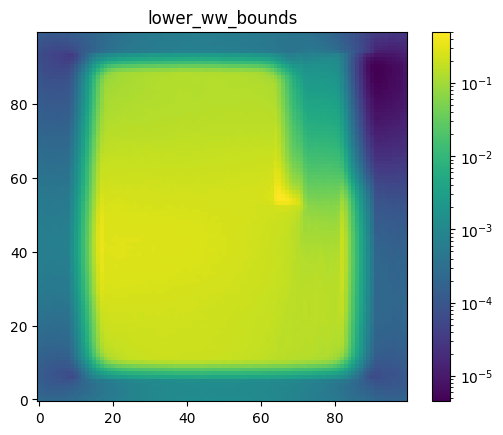

In [13]:
weight_windows = openmc.hdf5_to_wws('weight_windows.h5')
plt.imshow(
    weight_windows[0].lower_ww_bounds.squeeze().T,
    origin='lower',
    norm=LogNorm()
)
plt.title('lower_ww_bounds')
plt.colorbar()

# Use Weight Windows to Accelerate Original Continuous Energy Monte Carlo Solve

Now, to utilize the weight windows, we will add the weight windows into our settings object and configure things for continuous energy MC.

In [14]:
settings = openmc.Settings()

settings.weight_window_checkpoints = {'collision': True, 'surface': True}
settings.survival_biasing = False
settings.weight_windows = weight_windows
settings.particles = 40000
settings.batches = 12
settings.source = source
settings.run_mode = "fixed source"

tallies = openmc.Tallies([flux_tally])

First, to demonstrate the impacts of the weight windows, let's run OpenMC without using them and plot the relative error in the fluxes. Given that the shield is optically thick, many regions will receive no tallies and/or have very high errors.

In [15]:

settings.weight_windows_on = False # Turn off weight windows for now
simulation_using_ww_off = openmc.Model(geometry, materials_continuous_xs, settings, tallies)
statepoint = simulation_using_ww_off.run()


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading O16 from /home/jon/nuclear_data/neutron/O16.h5
 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5
 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5


 Reading Ar36 from /home/jon/nuclear_data/neutron/Ar36.h5
 Reading Ar38 from /home/jon/nuclear_data/neutron/Ar38.h5
 Reading Ar40 from /home/jon/nuclear_data/neutron/Ar40.h5
 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Reading C12 from /home/jon/nuclear_data/neutron/C12.h5


 Reading C13 from /home/jon/nuclear_data/neutron/C13.h5
 Reading Na23 from /home/jon/nuclear_data/neutron/Na23.h5
 Reading Mg24 from /home/jon/nuclear_data/neutron/Mg24.h5


 Reading Mg25 from /home/jon/nuclear_data/neutron/Mg25.h5
 Reading Mg26 from /home/jon/nuclear_data/neutron/Mg26.h5
 Reading Al27 from /home/jon/nuclear_data/neutron/Al27.h5


...

 Simulating batch 9


 Simulating batch 10


 Simulating batch 11


 Simulating batch 12


 Creating state point statepoint.12.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 4.6792e+00 seconds
   Reading cross sections          = 4.5984e+00 seconds
 Total time in simulation          = 2.7806e+01 seconds
   Time in transport only          = 2.7741e+01 seconds
   Time in active batches          = 2.7806e+01 seconds
   Time accumulating tallies       = 4.1961e-02 seconds
   Time writing statepoints        = 2.0970e-02 seconds
 Total time for finalization       = 5.6181e-02 seconds
 Total time elapsed                = 3.2557e+01 seconds
 Calculation Rate (active)         = 17262.2 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00193 +/- 0.00006



In [16]:
def plot_mesh_tally(statepoint_filename, image_filename):

    with openmc.StatePoint(statepoint_filename) as sp:
        flux_tally = sp.get_tally(name="flux tally")

    mesh_extent = flux_tally.find_filter(openmc.MeshFilter).mesh.bounding_box.extent['xy']

    # Create figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    # Plot flux mean on the left
    flux_mean = flux_tally.get_reshaped_data(value="mean", expand_dims=True).squeeze()
    im1 = axes[0].imshow(
        flux_mean[:, :].T,
        origin="lower",
        extent=mesh_extent,
        norm=LogNorm(),
    )
    axes[0].set_title("Flux")
    cbar1 = fig.colorbar(im1, ax=axes[0])
    cbar1.set_label("Flux")

    # Plot flux relative error on the right
    flux_rel_err = flux_tally.get_reshaped_data(value="rel_err", expand_dims=True).squeeze()
    im2 = axes[1].imshow(
        flux_rel_err[:, :].T,
        origin="lower",
        extent=mesh_extent,
        norm=LogNorm(),
    )
    axes[1].set_title("Flux Rel Err")
    cbar2 = fig.colorbar(im2, ax=axes[1])
    cbar2.set_label("Flux Rel Err")

    # Save the figure
    plt.savefig(image_filename)


/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/tallies.py:1377: RuntimeWarning: invalid value encountered in divide
  data = self.std_dev[indices] / self.mean[indices]


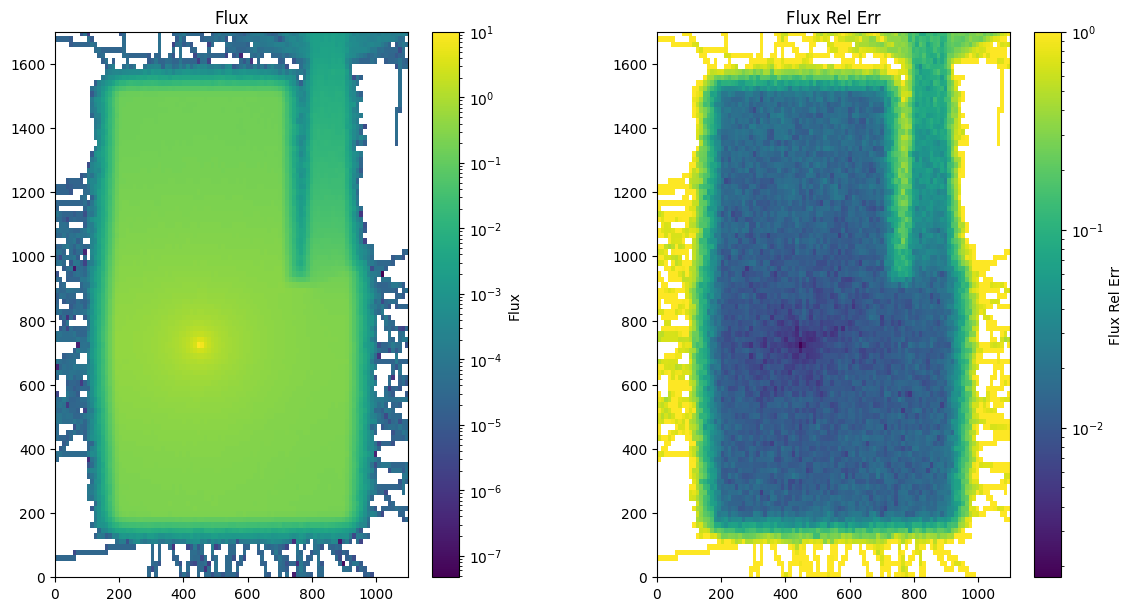

In [17]:
plot_mesh_tally(statepoint, "no_fw_cadis.png")

As expected, the error spikes quickly once entering the shield, with most areas deep into the shield receiving no tallies at all.

On this computer the simulation speed was 32553 particles per second for the simulation without weight windows and 6379 particles per second when weight windows were turned on. The particle splitting means individual particles take longer to simulate as the continue to be transported more.

So the simulation with weight window took longer to run and consumed more compute, to make this a fair comparison we should chage the particles per batch or batches so that the simulations both have the same compute.

Next, let's run OpenMC with weight windows enabled, and see the impact.

In [18]:
settings.weight_windows_on = True # Now, turn on the FW-CADIS generated weight windows
settings.batches = 2
simulation_using_ww_on = openmc.Model(geometry, materials_continuous_xs, settings, tallies)
statepoint = simulation_using_ww_on.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading O17 from /home/jon/nuclear_data/neutron/O17.h5
 Reading O18 from /home/jon/nuclear_data/neutron/O18.h5
 Reading Ar36 from /home/jon/nuclear_data/neutron/Ar36.h5
 Reading Ar38 from /home/jon/nuclear_data/neutron/Ar38.h5
 Reading Ar40 from /home/jon/nuclear_data/neutron/Ar40.h5


 Reading H1 from /home/jon/nuclear_data/neutron/H1.h5
 Reading H2 from /home/jon/nuclear_data/neutron/H2.h5
 Reading C12 from /home/jon/nuclear_data/neutron/C12.h5
 Reading C13 from /home/jon/nuclear_data/neutron/C13.h5
 Reading Na23 from /home/jon/nuclear_data/neutron/Na23.h5


 Reading Mg24 from /home/jon/nuclear_data/neutron/Mg24.h5
 Reading Mg25 from /home/jon/nuclear_data/neutron/Mg25.h5


 Reading Mg26 from /home/jon/nuclear_data/neutron/Mg26.h5
 Reading Al27 from /home/jon/nuclear_data/neutron/Al27.h5


...

 Reading Fe57 from /home/jon/nuclear_data/neutron/Fe57.h5


 Reading Fe58 from /home/jon/nuclear_data/neutron/Fe58.h5


 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000.0 eV for N15

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1


 Simulating batch 2


 Creating state point statepoint.2.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 5.2997e+00 seconds
   Reading cross sections          = 5.2125e+00 seconds
 Total time in simulation          = 1.7045e+01 seconds
   Time in transport only          = 1.7031e+01 seconds
   Time in active batches          = 1.7045e+01 seconds
   Time accumulating tallies       = 4.2441e-05 seconds
   Time writing statepoints        = 1.4341e-02 seconds
 Total time for finalization       = 3.1661e-02 seconds
 Total time elapsed                = 2.2395e+01 seconds
 Calculation Rate (active)         = 4693.39 particles/second

 ============================>     RESULTS     <============================

 Leakage Fraction            = 0.00200 +/- 0.00002



/home/jon/.neutronicsworkshop_3.12/lib/python3.12/site-packages/openmc/tallies.py:1377: RuntimeWarning: invalid value encountered in divide
  data = self.std_dev[indices] / self.mean[indices]


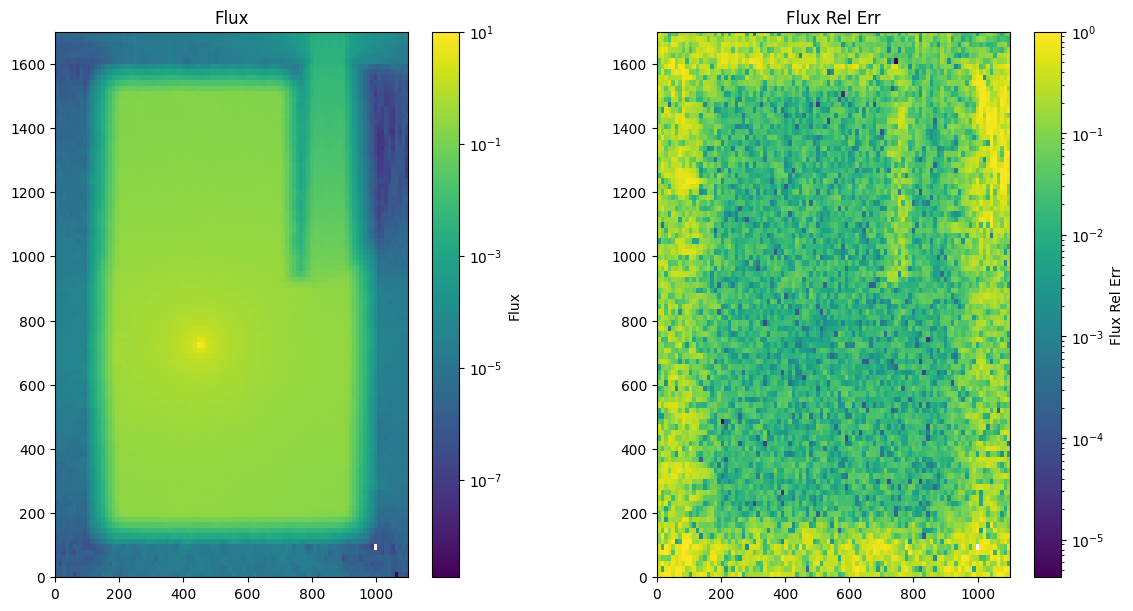

In [19]:
plot_mesh_tally(statepoint, "fw_cadis.png")